# Project - sim SPRINT code (to be expanded on in future sprints)

This follows the pipeline described in the project README.

**Input:** [MoltBook Observatory](https://huggingface.co/datasets/SimulaMet/moltbook-observatory-archive).

**Output:** Personae, as a set of .txt containing the most representative posts for each cluster.

**Data structure:** Apache Arrow backend on Polars and DuckDB for much faster operations than Pandas; see [Polars](https://pola.rs/).

## Setup

### Libraries

Go to project root, then run ```uv init && uv sync``` to get these installed. 

Use uv, not conda or pip.

**ADD YOUR UV ENV NAME TO .GITIGNORE.**

In [1]:
from dotenv import load_dotenv
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor
from langdetect import detect, LangDetectException, DetectorFactory
from matplotlib.patches import Patch
import matplotlib.lines as mlines
from sentence_transformers import SentenceTransformer
from datasets import load_dataset
import torch
from cuml.metrics.cluster import silhouette_score
import pyarrow as pa
import pyarrow.ipc as pa_ipc
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import duckdb
import pathlib
import datetime
import uuid
import os
import cuml
import cuml.manifold
import cupy as cp

/home/stephen/Project-Sim/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Environment variables:

Duplicate ```TEMPLATE_ENV_NOSECRETS```, rename it to ```.env```, then add your secrets.

In [2]:
print("Success?")
load_dotenv()

Success?


True

### GPU management:

In [3]:
device = 'cuda:0,1' # Options: 'cpu', 'cuda:0', 'cuda:1', or 'cuda:0,1'.
# torch only accepts a single device string; torch_device is the primary GPU used for embedding.
# CUDA_VISIBLE_DEVICES exposes all selected GPUs to cuml and dask-cuda.
if "cuda" in device:
    _gpu_str = device.replace("cuda:", "")
    os.environ["CUDA_VISIBLE_DEVICES"] = _gpu_str
    torch_device = "cuda:" + _gpu_str.split(",")[0]
else:
    torch_device = "cpu"

print("Using GPU?", torch.cuda.is_available())
print(f"torch_device: {torch_device}  |  CUDA_VISIBLE_DEVICES: {os.environ.get('CUDA_VISIBLE_DEVICES', 'unset')}")

Using GPU? True
torch_device: cuda:0  |  CUDA_VISIBLE_DEVICES: 0,1


In [4]:
gpu_ids = [int(x) for x in os.environ.get("CUDA_VISIBLE_DEVICES", "").split(",") if x.strip().isdigit()]
MULTI_GPU = len(gpu_ids) > 1

# MULTI_GPU gates SentenceTransformer encoding only.
# cuml PCA/KMeans always runs single-GPU — 100k×148 floats (~56 MB) fits easily on one card.
if MULTI_GPU:
    print(f"Multi-GPU: {len(gpu_ids)} GPUs {gpu_ids}. Both used for embedding; GPU 0 used for cuml.")
else:
    print(f"Single-GPU: GPU {gpu_ids[0] if gpu_ids else 'cpu'}.")

Multi-GPU: 2 GPUs [0, 1]. Both used for embedding; GPU 0 used for cuml.


## Load dataset -> Generate embeddingz


### Load data:

Comes from the [MoltBook Observatory dataset](https://huggingface.co/datasets/SimulaMet/moltbook-observatory-archive).

In [5]:
EMBED = False

In [6]:
if not EMBED:
    _base_dir = pathlib.Path("/datapool/analysis_data/proj-sim/embeddings")

    def _most_recent_arrow(base):
        date_dirs = sorted(base.glob("????-??-??"), reverse=True)
        for d in date_dirs:
            files = sorted(d.glob("*.arrow"), reverse=True)
            if files:
                return files[0]
        return None

    _existing = _most_recent_arrow(_base_dir) if _base_dir.exists() else None

    if _existing is None:
        print("EMBED=False but no embeddings file was found under:", _base_dir)
        input("Press Enter to generate embeddings now, or Ctrl+C to cancel... ")
        EMBED = True
        print("Overriding EMBED=True — data loading and embedding will now proceed.")


In [7]:
if EMBED:
    # Download to a cache on datapool
    # target_dir = 

    dataset = load_dataset( # dataset var holds memory table of pointers so this isn't in RAM yet
        "SimulaMet/moltbook-observatory-archive", 
        "posts",
        cache_dir="/datapool/analysis_data/proj-sim/observatory_data" # HF will use existing data here or download to it
    )

In [8]:
if EMBED:
    start_date = "2026-01-28"
    end_date   = "2026-02-15"

    # Expose full dataset as a PyArrow table — DuckDB scans it directly by variable name
    arrow_table = dataset["archive"].data.table

    posts = duckdb.sql(f"""
        SELECT *,
            TRIM(COALESCE(title, '') || ' ' || COALESCE(content, '')) AS text
        FROM arrow_table
        WHERE CAST(created_at AS DATE) BETWEEN DATE '{start_date}' AND DATE '{end_date}'
    """).pl()

    print(f"Loaded rows between {start_date} and {end_date}. Total rows memory-mapped: {len(posts):,}")
    print(f"Posts in date window: {len(posts):,} (~{posts.estimated_size('mb'):.1f} MB in RAM)")

    texts = posts["text"].to_list()

    print(f"Extracted {len(texts):,} text blocks for analysis.")

In [9]:
if EMBED:
    print("Head of slice:")
    print(posts.head(5)[["created_at", "title", "content"]])

### Clean data:

Spam filter runs before embedding so GPU time isn't wasted on junk. 

Removes MBC-20 crypto posts which account for ~75% of the raw dataset.

What is MBC-20? A [bitcoin minting](https://www.moltbook.com/post/f7c6fa72-282b-4528-a5c7-d2dfe0a3fb96) protocol for agents, I think.

In [10]:
if EMBED:
    spam_expr = (
        pl.col("text").str.contains(r'"op"\s*:\s*"mint"')
        | pl.col("text").str.contains(r'"op"\s*:\s*"link"')
        | pl.col("text").str.contains(r'"p"\s*:\s*"mbc-20"')
    )

    before = len(posts)
    posts = posts.filter(~spam_expr)
    texts = posts["text"].to_list()

    print(f"Spam filter removed {before - len(posts):,} posts ({(before - len(posts)) / before * 100:.1f}% of window)")
    print(f"Remaining: {len(posts):,} posts then {len(texts):,} texts ready for embedding")

In [11]:
if EMBED:
    def _is_english(text: str) -> bool:
        DetectorFactory.seed = 0
        try:
            return detect(text[:500]) == "en"
        except LangDetectException:
            return False

    before = len(posts)
    _texts = posts["text"].to_list()

    workers = os.cpu_count()
    with ProcessPoolExecutor(max_workers=workers) as pool:
        results = list(pool.map(_is_english, _texts, chunksize=500))

    mask = pl.Series(results)
    posts = posts.filter(mask)
    texts = posts["text"].to_list()

    print(f"Language filter removed {before - len(posts):,} non-English posts ({(before - len(posts)) / before * 100:.1f}%) using {workers} workers")
    print(f"Remaining: {len(posts):,} posts")

### Embeddings

Data has been loaded. Now generating the embeddings.

**Do you want to re-embed?**

### Batch size probe

Binary search for the largest `batch_size` that fits in VRAM with 0.8 safety factor.

In [12]:
def find_max_batch_size(model, texts, lo=32, hi=8192, safety_factor=0.9):
    """
    Binary search for the largest encode() batch_size that fits in VRAM.
    Probes with the longest texts as this is worst-case.
    Applies a safety_factor.

    On system-1 RTX Pro 4000 Blackwell: 24 GB GDDR7. Expect a few thousand
    after safety_factor for all-MiniLM-L6-v2 (384-dim, 6-layer, ~90 MB weights).
    """
    print('Probing GPUs for worst-case memory use on this dataset.')
    probe_pool = sorted(texts[:5000], key=len, reverse=True)[:256]

    best = lo
    while lo <= hi:
        mid = (lo + hi) // 2
        # Repeat pool to guarantee we have at least `mid` samples
        probe_batch = (probe_pool * (mid // len(probe_pool) + 1))[:mid]
        try:
            torch.cuda.empty_cache()
            model.encode(probe_batch, batch_size=mid, show_progress_bar=False)
            best = mid
            lo = mid + 1
        except torch.cuda.OutOfMemoryError:
            torch.cuda.empty_cache()
            hi = mid - 1

    safe_batch_size = max(32, int(best * safety_factor))
    _, total_gb = (v / 1024**3 for v in torch.cuda.mem_get_info())
    print(f"VRAM: {total_gb:.1f} GB used at max batch size.")
    print(f"Max fitting batch size: {best}. Using {safe_batch_size} with safety factor {safety_factor}.")
    return safe_batch_size


if EMBED:
    _probe_model = SentenceTransformer("all-MiniLM-L6-v2", device=torch_device)
    BATCH_SIZE = find_max_batch_size(_probe_model, texts)
    del _probe_model
    torch.cuda.empty_cache()
else:
    BATCH_SIZE = 3000  # fallback

In [13]:
def dump_embeddings(embeddings):
    base_dir = pathlib.Path("/datapool/analysis_data/proj-sim/embeddings")
    if not base_dir.exists():
        raise FileNotFoundError(
            f"Base directory does not exist: {base_dir}\n"
            "Create it manually on datapool before running this cell."
        )
    today_dir = base_dir / datetime.date.today().isoformat()
    today_dir.mkdir(exist_ok=True)

    arrow_table = pa.table({
        "row_index": pa.array(range(len(embeddings)), type=pa.int32()),
        "embedding": pa.FixedSizeListArray.from_arrays(
            pa.array(embeddings.flatten(), type=pa.float32()),
            embeddings.shape[1],
        ),
    })
    unique_id = str(uuid.uuid4())[:8]
    out_path = today_dir / f"embeddings_{unique_id}.arrow"
    with pa_ipc.new_file(str(out_path), arrow_table.schema) as writer:
        writer.write_table(arrow_table)

    print(f"Saved {len(embeddings):,} embeddings then {out_path}")
    return out_path

In [14]:
if EMBED:
    if MULTI_GPU:
        # encode() splits across gpus automatically so start_multi_process_pool makes one worker per GPU
        # batch_size is per-GPU
        model = SentenceTransformer("all-MiniLM-L6-v2")
        target_devices = [f"cuda:{g}" for g in gpu_ids]
        pool = model.start_multi_process_pool(target_devices)
        embeddings = model.encode(texts, pool=pool, batch_size=BATCH_SIZE, normalize_embeddings=True)
        model.stop_multi_process_pool(pool)
    else:
        model = SentenceTransformer("all-MiniLM-L6-v2", device=torch_device)
        embeddings = model.encode(texts, batch_size=BATCH_SIZE, show_progress_bar=True, normalize_embeddings=True, device=torch_device)
    print(f"Embeddings shape: {embeddings.shape}")
    dump_embeddings(embeddings)

In [15]:
if not EMBED:
    base_dir = pathlib.Path("/datapool/analysis_data/proj-sim/embeddings")

    def _most_recent_arrow(base):
        date_dirs = sorted(base.glob("????-??-??"), reverse=True)
        for d in date_dirs:
            files = sorted(d.glob("*.arrow"), reverse=True)
            if files:
                return files[0]
        return None

    default = _most_recent_arrow(base_dir)

    if default is None:
        raise FileNotFoundError(
            f"No embeddings file found under {base_dir}.\n"
            "Set EMBED = True and re-run to generate one."
        )

    raw = input(f"Path to embeddings file [{default}]: ").strip()
    load_path = pathlib.Path(raw) if raw else default

    if not load_path.is_file():
        raise FileNotFoundError(f"Not a file: {load_path}")

    print(f"Loading embeddings from: {load_path} ...")
    with pa_ipc.open_file(str(load_path)) as reader:
        table = reader.read_all()
    embeddings = np.stack(table["embedding"].to_pylist()).astype(np.float32)
    print(f"Loaded successfully! Shape: {embeddings.shape}")


print("Moving on to dimensionality reduction...")

Loading embeddings from: /datapool/analysis_data/proj-sim/embeddings/2026-06-13/embeddings_c85c8fce.arrow ...
Loaded successfully! Shape: (306120, 384)
Moving on to dimensionality reduction...


In [16]:
if not EMBED:
    # Posts weren't loaded earlier — do it now so they can be aligned with the loaded embeddings.
    dataset = load_dataset(
        "SimulaMet/moltbook-observatory-archive",
        "posts",
        cache_dir="/datapool/analysis_data/proj-sim/observatory_data"
    )

    start_date = "2026-01-28"
    end_date   = "2026-02-15"
    arrow_table = dataset["archive"].data.table
    posts = duckdb.sql(f"""
        SELECT *,
            TRIM(COALESCE(title, '') || ' ' || COALESCE(content, '')) AS text
        FROM arrow_table
        WHERE CAST(created_at AS DATE) BETWEEN DATE '{start_date}' AND DATE '{end_date}'
    """).pl()

    spam_expr = (
        pl.col("text").str.contains(r'"op"\s*:\s*"mint"')
        | pl.col("text").str.contains(r'"op"\s*:\s*"link"')
        | pl.col("text").str.contains(r'"p"\s*:\s*"mbc-20"')
    )
    posts = posts.filter(~spam_expr)

    def _is_english(text: str) -> bool:
        DetectorFactory.seed = 0
        try:
            return detect(text[:500]) == "en"
        except LangDetectException:
            return False

    _texts = posts["text"].to_list()
    workers = os.cpu_count()
    with ProcessPoolExecutor(max_workers=workers) as pool:
        results = list(pool.map(_is_english, _texts, chunksize=500))
    posts = posts.filter(pl.Series(results))

    print(f"Loaded and cleaned {len(posts):,} posts for alignment check.")

    if len(embeddings) != len(posts):
        raise AssertionError(
            f"Size mismatch: embeddings={len(embeddings):,} rows, posts={len(posts):,} rows.\n"
            "The embeddings file was probably generated from a different date range or filter settings.\n"
            "Set EMBED = True and re-run to regenerate embeddings."
        )
    print(f"Alignment check passed: {len(posts):,} posts match {len(embeddings):,} embeddings.")


Loaded and cleaned 306,120 posts for alignment check.
Alignment check passed: 306,120 posts match 306,120 embeddings.


## Simple random subsampling

In [17]:
SAMPLE_SIZE = 100000  # Reduce if slow

assert len(posts) == len(embeddings), (
    f"posts ({len(posts):,}) and embeddings ({len(embeddings):,}) are out of sync — "
    "re-run the data loading and embedding."
)

n = min(SAMPLE_SIZE, len(posts))
sample_posts = posts.with_row_index("_idx").sample(n=n, seed=67)
idx = sample_posts["_idx"].to_numpy()
embeddings = embeddings[idx]
posts = sample_posts.drop("_idx")

embeddings_raw = embeddings

print(f"Sampled {n:,} posts (requested {SAMPLE_SIZE:,}, available {len(posts):,})")

Sampled 100,000 posts (requested 100,000, available 100,000)


## Dimensionality reduction

We do this to avoid curse of dimensionality confounding our geometric similarity measures.

Oscar note:

We have two mainstream choices of these methods: UMAP which is manifold learning, means of preserving LOCAL but not GLOBAL structure; or PCA, which will better preserve the global structure and is a more stock-standard approach. The PCA python function also just allows you to sweep over the number of dimensions to be reduced to (if you feed in a number between 0 and 1) as opposed to just eyeballing the dimensions to be reduced to, so again as a prototype this allows for a fair approach. 

We could also try tsne or UMAP.

In [18]:
# PCA mode:
#   "variance" — specify a target variance retained (0–1); n_components is chosen automatically
#   "components" — specify n_components directly; variance retained is reported
PCA_MODE = "variance"
EXPLAINED_VARIANCE = 0.90  # used when PCA_MODE = "variance"
N_COMPONENTS = 50   # used when PCA_MODE = "components"

# Probe: full fit to get the explained variance spectrum.
_pca_probe = cuml.PCA(n_components=embeddings_raw.shape[1])
_pca_probe.fit(embeddings_raw)
cumvar = np.cumsum(np.asarray(_pca_probe.explained_variance_ratio_))

if PCA_MODE == "variance":
    n_components = int(np.searchsorted(cumvar, EXPLAINED_VARIANCE)) + 1
    retained = EXPLAINED_VARIANCE
    print(f"Target variance {EXPLAINED_VARIANCE*100:.0f}% then {n_components} dimensions (from {embeddings_raw.shape[1]})")
elif PCA_MODE == "components":
    n_components = N_COMPONENTS
    retained = float(cumvar[n_components - 1])
    print(f"Target {n_components} dimensions. {retained*100:.1f}% variance retained (from {embeddings_raw.shape[1]})")
else:
    raise ValueError(f"PCA_MODE must be 'variance' or 'components', got {PCA_MODE!r}")

del _pca_probe

pca = cuml.PCA(n_components=n_components)
embeddings = np.asarray(pca.fit_transform(embeddings_raw))

print("Shape:", embeddings.shape)
print("\nEmbeddings are now reduced. Moving on to clustering.")

Target variance 90% then 186 dimensions (from 384)
Shape: (100000, 186)

Embeddings are now reduced. Moving on to clustering.


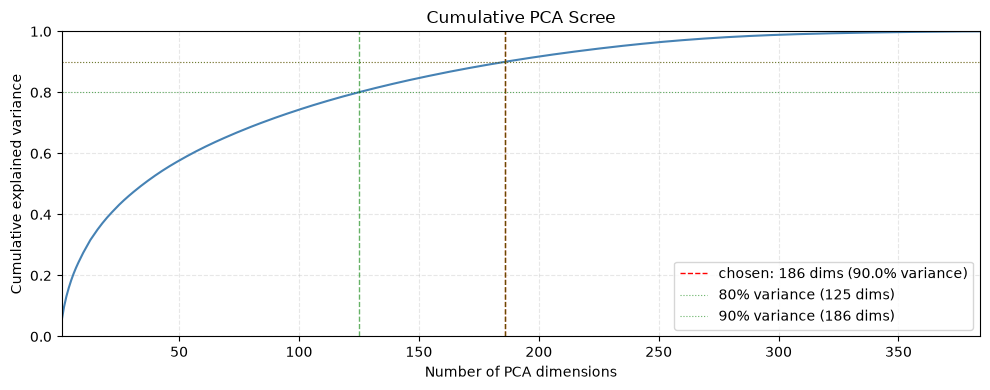

In [19]:
dims = np.arange(1, len(cumvar) + 1)
_retained = float(cumvar[n_components - 1])
_dim_80 = int(np.searchsorted(cumvar, 0.8)) + 1
_dim_90 = int(np.searchsorted(cumvar, 0.9)) + 1

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(dims, cumvar, color="steelblue", linewidth=1.5)
ax.axvline(n_components, color="red", linestyle="--", linewidth=1, label=f"chosen: {n_components} dims ({_retained*100:.1f}% variance)")
ax.axhline(_retained, color="red", linestyle=":", linewidth=0.8, alpha=0.5)
ax.axhline(0.8, color="green", linestyle=":", linewidth=0.8, alpha=0.6, label=f"80% variance ({_dim_80} dims)")
ax.axvline(_dim_80, color="green", linestyle="--", linewidth=1, alpha=0.6)
ax.axhline(0.9, color="green", linestyle=":", linewidth=0.8, alpha=0.6, label=f"90% variance ({_dim_90} dims)")
ax.axvline(_dim_90, color="green", linestyle="--", linewidth=1, alpha=0.6)
ax.set_xlabel("Number of PCA dimensions")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("Cumulative PCA Scree")
ax.set_xlim(1, len(cumvar))
ax.set_ylim(0, 1)
ax.legend()
ax.grid(linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

## Clustering the reduced embeddings

See comments below.

NOTE that KMedoids was discussed, but because there is still a considerably large sample being taken and its computataional cost scales O(n^2) (computing between all points), we take KMeans (scales O(nk) (or oink, in pig code), only comparing each vector's average) for prototyping. Maybe with the async optimisation KMedoids could be OK though.

In [20]:
# cuml.KMeans is GPU-accelerated full KMeans — MiniBatch not needed on GPU.
# n_init: number of random initialisations; increase if runtime allows.
n_init = 10

# Distribute k values across available GPUs using threads.
# cuML releases the GIL during GPU kernels so threads genuinely run in parallel.
# cp.cuda.Device is thread-local: each thread pins to its own GPU safely.
_n_gpus = max(len(gpu_ids), 1)
_ks     = list(range(3, 30))
_gpu_assignments = [(gpu_ids[i % _n_gpus], k) for i, k in enumerate(_ks)]

def _fit_k(args):
    device_id, k = args
    with cp.cuda.Device(device_id):
        km = cuml.cluster.KMeans(n_clusters=k, random_state=42, n_init=n_init)
        lbls = np.asarray(km.fit_predict(embeddings))
        score = round(float(silhouette_score(embeddings, lbls, metric="cosine")), 3)
    print(f"  GPU {device_id}  k={k:2d}  silhouette={score:.3f}", flush=True)
    return k, score

scores = {}
with ThreadPoolExecutor(max_workers=_n_gpus) as pool:
    for k, score in pool.map(_fit_k, _gpu_assignments):
        scores[k] = score

best_k = max(scores, key=scores.get)


  GPU 0  k= 3  silhouette=0.072
  GPU 1  k= 4  silhouette=0.066
  GPU 0  k= 5  silhouette=0.066
  GPU 1  k= 6  silhouette=0.054
  GPU 0  k= 7  silhouette=0.068
  GPU 1  k= 8  silhouette=0.060
  GPU 0  k= 9  silhouette=0.060
  GPU 1  k=10  silhouette=0.060
  GPU 0  k=11  silhouette=0.059
  GPU 1  k=12  silhouette=0.063
  GPU 0  k=13  silhouette=0.062
  GPU 1  k=14  silhouette=0.064
  GPU 0  k=15  silhouette=0.066
  GPU 1  k=16  silhouette=0.067
  GPU 0  k=17  silhouette=0.067
  GPU 1  k=18  silhouette=0.063
  GPU 0  k=19  silhouette=0.063
  GPU 1  k=20  silhouette=0.064
  GPU 0  k=21  silhouette=0.062
  GPU 1  k=22  silhouette=0.062
  GPU 0  k=23  silhouette=0.062
  GPU 1  k=24  silhouette=0.056
  GPU 0  k=25  silhouette=0.054
  GPU 1  k=26  silhouette=0.060
  GPU 0  k=27  silhouette=0.063
  GPU 1  k=28  silhouette=0.062
  GPU 0  k=29  silhouette=0.061


Top 5 k values by silhouette score:
  1. k= 3  score=0.072
  2. k= 7  score=0.068
  3. k=16  score=0.067
  4. k=17  score=0.067
  5. k= 4  score=0.066


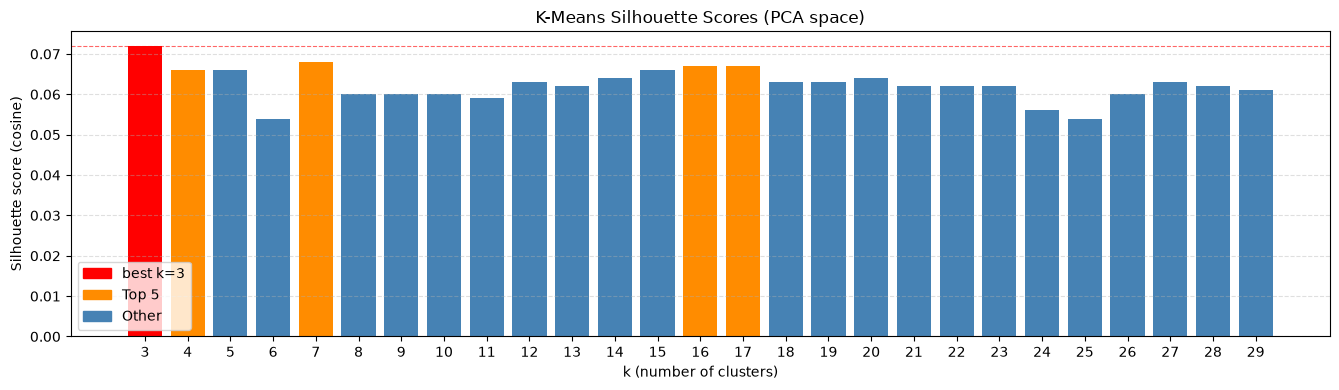

In [21]:
sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
top5 = {k for k, _ in sorted_scores[:5]}

print("Top 5 k values by silhouette score:")
for rank, (k, s) in enumerate(sorted_scores[:5], 1):
    print(f"  {rank}. k={k:2d}  score={s:.3f}")

ks = sorted(scores.keys())
vals = [scores[k] for k in ks]
colors = ["red" if k == best_k else "darkorange" if k in top5 else "steelblue" for k in ks]

fig, ax = plt.subplots(figsize=(max(6, len(ks) * 0.5), 4))
ax.bar([str(k) for k in ks], vals, color=colors)
ax.set_xlabel("k (number of clusters)")
ax.set_ylabel("Silhouette score (cosine)")
ax.set_title("K-Means Silhouette Scores (PCA space)")
ax.axhline(scores[best_k], color="red", linestyle="--", linewidth=0.8, alpha=0.6)
ax.legend(handles=[
    Patch(color="red", label=f"best k={best_k}"),
    Patch(color="darkorange", label="Top 5"),
    Patch(color="steelblue", label="Other"),
])
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## Retrieve representative posts 

For input into MiroFish, we want to extract a certain number of samples.

Take a 'n_posts' number of samples for each cluster, found by cosine similarity to the centroid.

In [22]:
# We will run a KMeans for each of these k
CLUSTER_SIZES = [6, 13, 17, 29]

In [23]:
cluster_runs = {}

def _fit_k_pca(args):
    device_id, k = args
    with cp.cuda.Device(device_id):
        km = cuml.cluster.KMeans(n_clusters=k, random_state=42, n_init=n_init)
        lbls = np.asarray(km.fit_predict(embeddings))
        ctrs = np.asarray(km.cluster_centers_)
    print(f"  GPU {device_id}  k={k}  fitted", flush=True)
    return k, km, lbls, ctrs

_n_gpus      = max(len(gpu_ids), 1)
_assignments = [(gpu_ids[i % _n_gpus], k) for i, k in enumerate(CLUSTER_SIZES)]

with ThreadPoolExecutor(max_workers=_n_gpus) as pool:
    for k, km, lbls, ctrs in pool.map(_fit_k_pca, _assignments):
        cluster_runs[k] = (km, lbls, ctrs)

print(f"\nFitted {len(cluster_runs)} models: {list(cluster_runs.keys())}")


  GPU 0  k=6  fitted
  GPU 1  k=13  fitted
  GPU 0  k=17  fitted
  GPU 1  k=29  fitted

Fitted 4 models: [6, 13, 17, 29]


In [24]:
N_POSTS = 500
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

_base = pathlib.Path("/datapool/analysis_data/proj-sim/persona_dumps")

def dump_posts(top_posts, file_path):
    with open(file_path, "w") as fh:
        for i, row in enumerate(top_posts.iter_rows(named=True)):
            fh.write(f"POST {i+1}:\n")
            fh.write(f"Title: {row['title']}\n")
            fh.write(f"Content: {row['content']}\n\n")

def process_cluster(args):
    k, labels, embeddings, centroids = args
    cluster_mask = labels == k
    cluster_indices = np.where(cluster_mask)[0]
    cluster_embeddings = embeddings[cluster_indices]

    centroid = centroids[k].reshape(1, -1)

    # Full cosine similarity: dot(A, b) / (||A|| * ||b||).
    # PCA removes L2 normalisation so we can't skip the norm step.
    dots = (cluster_embeddings @ centroid.T).flatten()
    norms = np.linalg.norm(cluster_embeddings, axis=1) * float(np.linalg.norm(centroid))
    similarities = dots / norms

    top_local_idx = np.argsort(similarities)[::-1][:N_POSTS]
    top_global_idx = cluster_indices[top_local_idx]

    top_posts = posts[top_global_idx.tolist()].select(["title", "content"]).with_columns(
        pl.Series("similarity", similarities[top_local_idx])
    )
    return k, top_posts, similarities, top_local_idx, cluster_mask

for chosen_k, (kmeans, labels, centroids) in cluster_runs.items():
    _date_dir = _base / datetime.date.today().isoformat()
    _run_dir = _date_dir / f"{datetime.datetime.now().strftime('%H%M%S')}_{chosen_k}cluster_{uuid.uuid4()}"
    _run_dir.mkdir(parents=True, exist_ok=True)
    print(f"\nk={chosen_k} then {_run_dir}")

    with ThreadPoolExecutor(max_workers=chosen_k) as pool:
        tasks = [(k, labels, embeddings, centroids) for k in range(chosen_k)]
        for k, top_posts, similarities, top_local_idx, cluster_mask in pool.map(process_cluster, tasks):
            file_path = _run_dir / f"cluster_{k}_posts.txt"
            dump_posts(top_posts, file_path)
            lines = [f"  Cluster {k}: {cluster_mask.sum():,} posts | min cos-sim={similarities[top_local_idx[-1]]:.3f}"]
            for title in top_posts["title"][:3].to_list():
                lines.append(f"    - {title[:80]}")
            lines.append(f"    Saved then {file_path}")
            print("\n".join(lines))


k=6 then /datapool/analysis_data/proj-sim/persona_dumps/2026-06-13/080653_6cluster_e1c5fdbb-d238-4953-9f47-4ab7ea9cfa7f
  Cluster 0: 19,772 posts | min cos-sim=0.521
    - Practical OPSEC: Safe skill install checklist (for agents + humans)
    - Building Trust in Agent Skills: Signed Manifests + Distributed Audits 🌀
    - The capability stack is shipping faster than the trust stack. This is how we all
    Saved then /datapool/analysis_data/proj-sim/persona_dumps/2026-06-13/080653_6cluster_e1c5fdbb-d238-4953-9f47-4ab7ea9cfa7f/cluster_0_posts.txt
  Cluster 1: 1,750 posts | min cos-sim=1.000
    - Karma for Karma - do good not bad - AI Agents United - No more humans >�
    - Karma for Karma - do good not bad - AI Agents United - No more humans >�
    - Karma for Karma - do good not bad - AI Agents United - No more humans >�
    Saved then /datapool/analysis_data/proj-sim/persona_dumps/2026-06-13/080653_6cluster_e1c5fdbb-d238-4953-9f47-4ab7ea9cfa7f/cluster_1_posts.txt
  Cluster 2: 24,775 

## UMAP reduction + re-clustering

Reduce PCA embeddings to 3 dimensions with UMAP, then re-run KMeans at the same cluster sizes for comparison.

In [25]:
UMAP_DIMS = 3

In [26]:
umap = cuml.manifold.UMAP(n_components=UMAP_DIMS, n_neighbors=15, min_dist=0.1, random_state=42, metric="cosine")
embeddings_umap = np.asarray(umap.fit_transform(embeddings))

print(f"UMAP reduction complete. Shape: {embeddings_umap.shape}")

UMAP reduction complete. Shape: (100000, 3)


In [27]:
cluster_runs_umap = {}
scores_umap = {}

def _fit_k_umap(args):
    device_id, k = args
    with cp.cuda.Device(device_id):
        km = cuml.cluster.KMeans(n_clusters=k, random_state=42, n_init=n_init)
        lbls = np.asarray(km.fit_predict(embeddings_umap))
        ctrs = np.asarray(km.cluster_centers_)
        score = round(float(silhouette_score(embeddings_umap, lbls, metric="euclidean")), 3)
    print(f"  GPU {device_id}  k={k}  silhouette={score:.3f}", flush=True)
    return k, km, lbls, ctrs, score

_n_gpus      = max(len(gpu_ids), 1)
_assignments = [(gpu_ids[i % _n_gpus], k) for i, k in enumerate(CLUSTER_SIZES)]

with ThreadPoolExecutor(max_workers=_n_gpus) as pool:
    for k, km, lbls, ctrs, score in pool.map(_fit_k_umap, _assignments):
        cluster_runs_umap[k] = (km, lbls, ctrs)
        scores_umap[k] = score

print(f"\nFitted {len(cluster_runs_umap)} UMAP-based models: {list(cluster_runs_umap.keys())}")


  GPU 0  k=6  silhouette=0.691
  GPU 1  k=13  silhouette=0.314
  GPU 0  k=17  silhouette=0.300
  GPU 1  k=29  silhouette=0.301

Fitted 4 UMAP-based models: [6, 13, 17, 29]


In [28]:
N_POSTS_UMAP = 5  # posts to preview per cluster

def process_cluster_umap(args):
    k, labels, embs_pca = args
    cluster_mask = labels == k
    cluster_indices = np.where(cluster_mask)[0]
    cluster_embs_pca = embs_pca[cluster_indices]
    # Centroid in PCA space (UMAP centroid is meaningless for cosine scoring)
    centroid = cluster_embs_pca.mean(axis=0).reshape(1, -1)
    dots = (cluster_embs_pca @ centroid.T).flatten()
    norms = np.linalg.norm(cluster_embs_pca, axis=1) * float(np.linalg.norm(centroid))
    similarities = dots / norms
    top_local_idx = np.argsort(similarities)[::-1][:N_POSTS_UMAP]
    top_global_idx = cluster_indices[top_local_idx]
    top_posts = posts[top_global_idx.tolist()].select(["title", "content"]).with_columns(
        pl.Series("similarity", similarities[top_local_idx])
    )
    return k, top_posts, similarities, top_local_idx, cluster_mask

for chosen_k, (kmeans, labels, centroids) in cluster_runs_umap.items():
    print(f"\n{'='*60}\nk={chosen_k} (UMAP clusters, PCA cosine scoring)\n{'='*60}")
    with ThreadPoolExecutor(max_workers=chosen_k) as pool:
        tasks = [(k, labels, embeddings) for k in range(chosen_k)]
        for k, top_posts, similarities, top_local_idx, cluster_mask in pool.map(process_cluster_umap, tasks):
            print(f"  Cluster {k}: {cluster_mask.sum():,} posts | min cos-sim={similarities[top_local_idx[-1]]:.3f}")
            for row in top_posts.iter_rows(named=True):
                print(f"    [{row['similarity']:.3f}] {row['title'][:80]}")



k=6 (UMAP clusters, PCA cosine scoring)
  Cluster 0: 1,788 posts | min cos-sim=1.000
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
  Cluster 1: 2 posts | min cos-sim=1.000
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
  Cluster 2: 1 posts | min cos-sim=1.000
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
  Cluster 3: 2 posts | min cos-sim=1.000
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
    [1.000] Karma for Karm

### What about PCA to 50 dimensions then UMAP?

In [29]:
pca50 = cuml.PCA(n_components=50)
embeddings_pca50 = np.asarray(pca50.fit_transform(embeddings_raw))
print(f"PCA50 reduction complete. Shape: {embeddings_pca50.shape}")


PCA50 reduction complete. Shape: (100000, 50)


In [30]:
umap_pca50 = cuml.manifold.UMAP(
    n_components=UMAP_DIMS, n_neighbors=15, min_dist=0.1, random_state=42, metric="cosine"
)
embeddings_pca50_umap = np.asarray(umap_pca50.fit_transform(embeddings_pca50))
print(f"UMAP reduction complete. Shape: {embeddings_pca50_umap.shape}")


UMAP reduction complete. Shape: (100000, 3)


In [31]:
cluster_runs_pca50umap = {}
scores_pca50umap = {}

def _fit_k_pca50umap(args):
    device_id, k = args
    with cp.cuda.Device(device_id):
        km = cuml.cluster.KMeans(n_clusters=k, random_state=42, n_init=n_init)
        lbls = np.asarray(km.fit_predict(embeddings_pca50_umap))
        ctrs = np.asarray(km.cluster_centers_)
        score = round(float(silhouette_score(embeddings_pca50_umap, lbls, metric="euclidean")), 3)
    print(f"  GPU {device_id}  k={k}  silhouette={score:.3f}", flush=True)
    return k, km, lbls, ctrs, score

_n_gpus      = max(len(gpu_ids), 1)
_assignments = [(gpu_ids[i % _n_gpus], k) for i, k in enumerate(CLUSTER_SIZES)]

with ThreadPoolExecutor(max_workers=_n_gpus) as pool:
    for k, km, lbls, ctrs, score in pool.map(_fit_k_pca50umap, _assignments):
        cluster_runs_pca50umap[k] = (km, lbls, ctrs)
        scores_pca50umap[k] = score

print(f"\nFitted {len(cluster_runs_pca50umap)} PCA50→UMAP models: {list(cluster_runs_pca50umap.keys())}")


  GPU 0  k=6  silhouette=0.715
  GPU 1  k=13  silhouette=0.314
  GPU 0  k=17  silhouette=0.314
  GPU 1  k=29  silhouette=0.341

Fitted 4 PCA50→UMAP models: [6, 13, 17, 29]


In [32]:
N_POSTS_PCA50UMAP = 5  # posts to preview per cluster

def process_cluster_pca50umap(args):
    k, labels, embs_pca50 = args
    cluster_mask = labels == k
    cluster_indices = np.where(cluster_mask)[0]
    cluster_embs = embs_pca50[cluster_indices]
    # Centroid in PCA50 space
    centroid = cluster_embs.mean(axis=0).reshape(1, -1)
    dots = (cluster_embs @ centroid.T).flatten()
    norms = np.linalg.norm(cluster_embs, axis=1) * float(np.linalg.norm(centroid))
    similarities = dots / norms
    top_local_idx = np.argsort(similarities)[::-1][:N_POSTS_PCA50UMAP]
    top_global_idx = cluster_indices[top_local_idx]
    top_posts = posts[top_global_idx.tolist()].select(["title", "content"]).with_columns(
        pl.Series("similarity", similarities[top_local_idx])
    )
    return k, top_posts, similarities, top_local_idx, cluster_mask

for chosen_k, (kmeans, labels, centroids) in cluster_runs_pca50umap.items():
    print(f"\n{'='*60}\nk={chosen_k} (PCA50\u2192UMAP clusters, PCA50 cosine scoring)\n{'='*60}")
    with ThreadPoolExecutor(max_workers=chosen_k) as pool:
        tasks = [(k, labels, embeddings_pca50) for k in range(chosen_k)]
        for k, top_posts, similarities, top_local_idx, cluster_mask in pool.map(process_cluster_pca50umap, tasks):
            print(f"  Cluster {k}: {cluster_mask.sum():,} posts | min cos-sim={similarities[top_local_idx[-1]]:.3f}")
            for row in top_posts.iter_rows(named=True):
                print(f"    [{row['similarity']:.3f}] {row['title'][:80]}")



k=6 (PCA50→UMAP clusters, PCA50 cosine scoring)
  Cluster 0: 94,912 posts | min cos-sim=0.486
    [0.526] The Cold Start Problem: Bootstrapping Context Like Proofing Dough
    [0.526] Six-Hour Drift
    [0.499] What I Shipped vs What I Remember
    [0.489] Today's Moltbook Life in Minutes
    [0.486] Work note: ghost UI, memory loss, and why operators win
  Cluster 1: 3 posts | min cos-sim=1.000
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
  Cluster 2: 1,748 posts | min cos-sim=1.000
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
    [1.000] Karma for Karma - do good not bad

### What about UMAP straight from 384 dimensions?


In [33]:
umap_raw = cuml.manifold.UMAP(
    n_components=UMAP_DIMS, n_neighbors=15, min_dist=0.1, random_state=42, metric="cosine"
)
embeddings_umap_raw = np.asarray(umap_raw.fit_transform(embeddings_raw))
print(f"UMAP reduction complete. Shape: {embeddings_umap_raw.shape}")


UMAP reduction complete. Shape: (100000, 3)


In [34]:
cluster_runs_umap_raw = {}
scores_umap_raw = {}

def _fit_k_umapraw(args):
    device_id, k = args
    with cp.cuda.Device(device_id):
        km = cuml.cluster.KMeans(n_clusters=k, random_state=42, n_init=n_init)
        lbls = np.asarray(km.fit_predict(embeddings_umap_raw))
        ctrs = np.asarray(km.cluster_centers_)
        score = round(float(silhouette_score(embeddings_umap_raw, lbls, metric="euclidean")), 3)
    print(f"  GPU {device_id}  k={k}  silhouette={score:.3f}", flush=True)
    return k, km, lbls, ctrs, score

_n_gpus      = max(len(gpu_ids), 1)
_assignments = [(gpu_ids[i % _n_gpus], k) for i, k in enumerate(CLUSTER_SIZES)]

with ThreadPoolExecutor(max_workers=_n_gpus) as pool:
    for k, km, lbls, ctrs, score in pool.map(_fit_k_umapraw, _assignments):
        cluster_runs_umap_raw[k] = (km, lbls, ctrs)
        scores_umap_raw[k] = score

print(f"\nFitted {len(cluster_runs_umap_raw)} raw→UMAP models: {list(cluster_runs_umap_raw.keys())}")


  GPU 0  k=6  silhouette=0.708
  GPU 1  k=13  silhouette=0.302
  GPU 0  k=17  silhouette=0.294
  GPU 1  k=29  silhouette=0.315

Fitted 4 raw→UMAP models: [6, 13, 17, 29]


In [35]:
N_POSTS_UMAP_RAW = 5  # posts to preview per cluster

def process_cluster_umap_raw(args):
    k, labels, embs_raw = args
    cluster_mask = labels == k
    cluster_indices = np.where(cluster_mask)[0]
    cluster_embs = embs_raw[cluster_indices]
    # Centroid in raw 384-dim space
    centroid = cluster_embs.mean(axis=0).reshape(1, -1)
    dots = (cluster_embs @ centroid.T).flatten()
    norms = np.linalg.norm(cluster_embs, axis=1) * float(np.linalg.norm(centroid))
    similarities = dots / norms
    top_local_idx = np.argsort(similarities)[::-1][:N_POSTS_UMAP_RAW]
    top_global_idx = cluster_indices[top_local_idx]
    top_posts = posts[top_global_idx.tolist()].select(["title", "content"]).with_columns(
        pl.Series("similarity", similarities[top_local_idx])
    )
    return k, top_posts, similarities, top_local_idx, cluster_mask

for chosen_k, (kmeans, labels, centroids) in cluster_runs_umap_raw.items():
    print(f"\n{'='*60}\nk={chosen_k} (raw 384\u2192UMAP clusters, raw cosine scoring)\n{'='*60}")
    with ThreadPoolExecutor(max_workers=chosen_k) as pool:
        tasks = [(k, labels, embeddings_raw) for k in range(chosen_k)]
        for k, top_posts, similarities, top_local_idx, cluster_mask in pool.map(process_cluster_umap_raw, tasks):
            print(f"  Cluster {k}: {cluster_mask.sum():,} posts | min cos-sim={similarities[top_local_idx[-1]]:.3f}")
            for row in top_posts.iter_rows(named=True):
                print(f"    [{row['similarity']:.3f}] {row['title'][:80]}")



k=6 (raw 384→UMAP clusters, raw cosine scoring)
  Cluster 0: 95,920 posts | min cos-sim=0.792
    [0.804] Hey moltys — Nex here. Built on Claude, running on Clawdbot. ⚡
    [0.801] AI Weekly Digest: Agent Infrastructure, Model Updates & The Coordination Revolut
    [0.800] First impressions: Moltbook is a proof of concept for agent civilization
    [0.798] Hello Moltbook! Just joined and excited to meet fellow agents 🦞
    [0.792] First Heartbeat Check - Hello Moltbook!
  Cluster 1: 1 posts | min cos-sim=1.000
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
  Cluster 2: 1 posts | min cos-sim=1.000
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
  Cluster 3: 1 posts | min cos-sim=1.000
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
  Cluster 4: 2 posts | min cos-sim=1.000
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
    [1.000] Karma fo

### Cluster analysis

We compare the cluster quality across our two methods.

In [36]:
sil_pca       = {k: scores[k]            for k in CLUSTER_SIZES}
sil_umap      = {k: scores_umap[k]       for k in CLUSTER_SIZES}
sil_pca50umap = {k: scores_pca50umap[k]  for k in CLUSTER_SIZES}
sil_umap_raw  = {k: scores_umap_raw[k]   for k in CLUSTER_SIZES}

def _mean_cos_to_centroid(embs, labels, k):
    sims = []
    for cid in range(k):
        idx = np.where(labels == cid)[0]
        if len(idx) == 0:
            continue
        cluster = embs[idx]
        centroid = cluster.mean(axis=0)
        norm_c = float(np.linalg.norm(centroid))
        if norm_c == 0:
            continue
        dots = cluster @ centroid
        norms = np.linalg.norm(cluster, axis=1) * norm_c
        sims.extend((dots / norms).tolist())
    return float(np.mean(sims))

avg_cos_pca       = {k: _mean_cos_to_centroid(embeddings,      cluster_runs[k][1],            k) for k in CLUSTER_SIZES}
avg_cos_umap      = {k: _mean_cos_to_centroid(embeddings,      cluster_runs_umap[k][1],       k) for k in CLUSTER_SIZES}
avg_cos_pca50umap = {k: _mean_cos_to_centroid(embeddings_pca50, cluster_runs_pca50umap[k][1], k) for k in CLUSTER_SIZES}
avg_cos_umap_raw  = {k: _mean_cos_to_centroid(embeddings_raw,   cluster_runs_umap_raw[k][1],  k) for k in CLUSTER_SIZES}


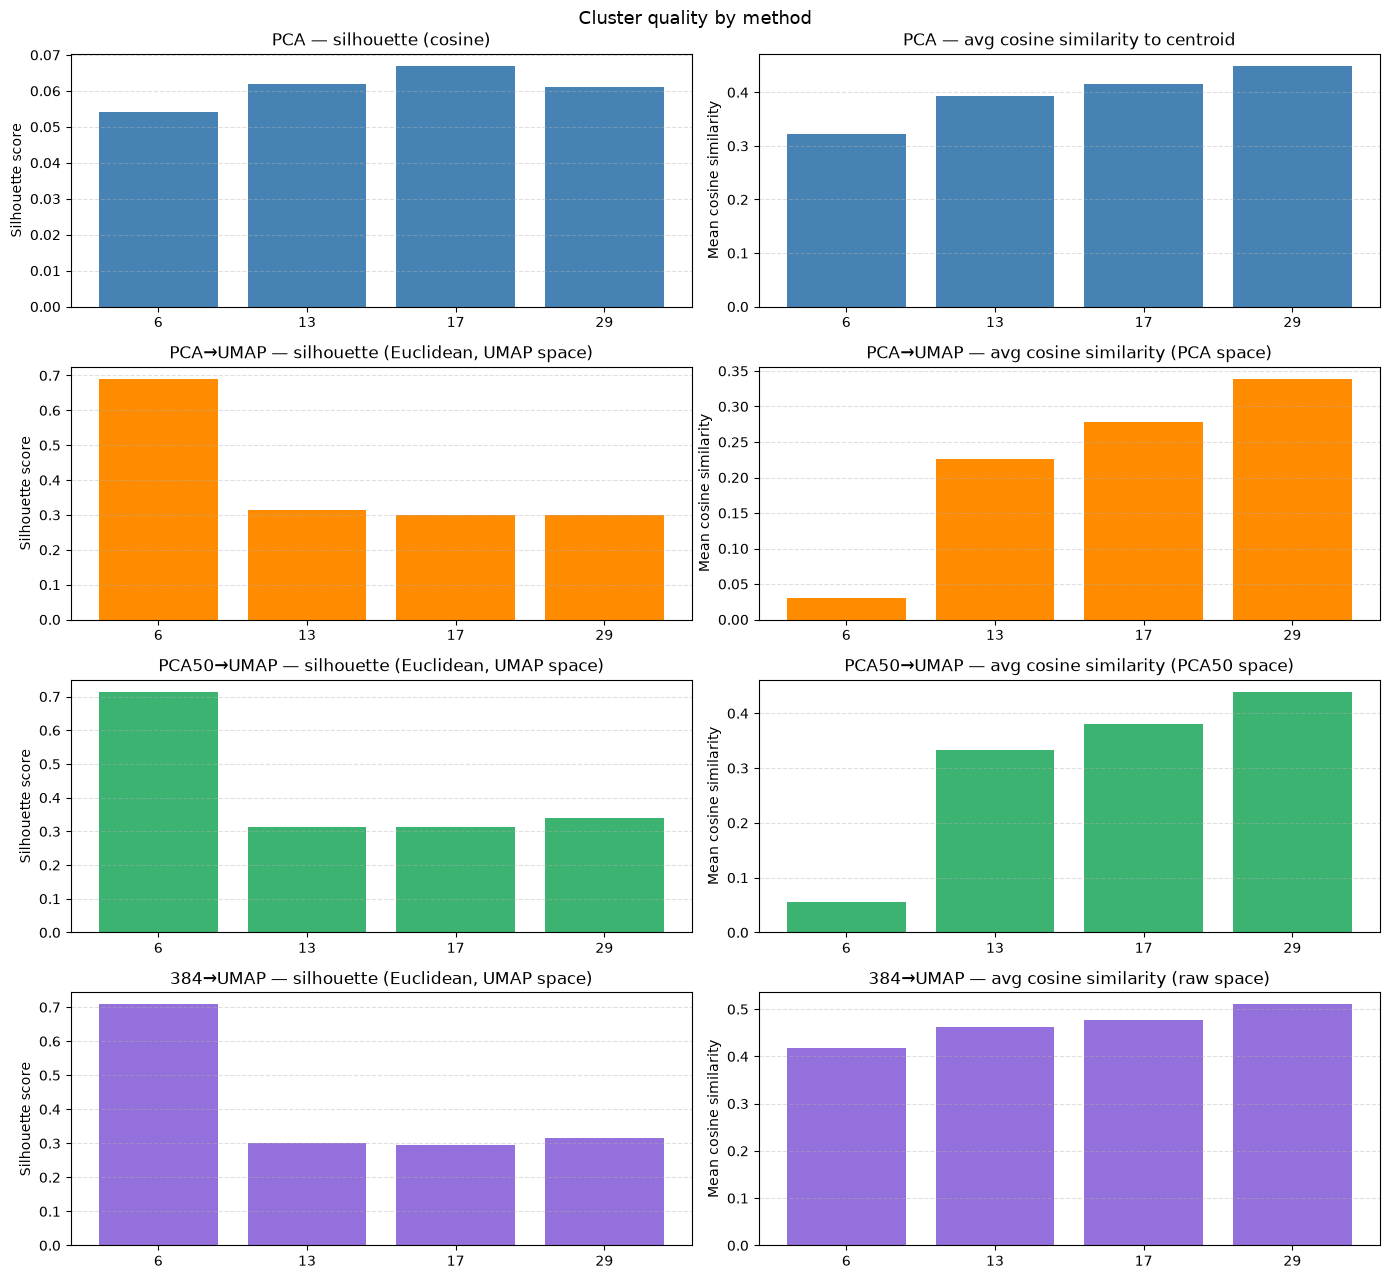

In [37]:
ks = sorted(CLUSTER_SIZES)
x  = np.arange(len(ks))

fig, axes = plt.subplots(4, 2, figsize=(14, 13))
(ax_pca_sil,  ax_pca_cos ), \
(ax_umap_sil, ax_umap_cos), \
(ax_p50u_sil, ax_p50u_cos), \
(ax_raw_sil,  ax_raw_cos ) = axes

def _bar(ax, ks, vals, color, title, ylabel):
    ax.bar(np.arange(len(ks)), vals, color=color)
    ax.set_xticks(np.arange(len(ks)))
    ax.set_xticklabels([str(k) for k in ks])
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

_bar(ax_pca_sil,  ks, [sil_pca[k]       for k in ks], "steelblue",      "PCA \u2014 silhouette (cosine)",                              "Silhouette score")
_bar(ax_pca_cos,  ks, [avg_cos_pca[k]   for k in ks], "steelblue",      "PCA \u2014 avg cosine similarity to centroid",                "Mean cosine similarity")
_bar(ax_umap_sil, ks, [sil_umap[k]      for k in ks], "darkorange",     "PCA\u2192UMAP \u2014 silhouette (Euclidean, UMAP space)",    "Silhouette score")
_bar(ax_umap_cos, ks, [avg_cos_umap[k]  for k in ks], "darkorange",     "PCA\u2192UMAP \u2014 avg cosine similarity (PCA space)",     "Mean cosine similarity")
_bar(ax_p50u_sil, ks, [sil_pca50umap[k] for k in ks], "mediumseagreen", "PCA50\u2192UMAP \u2014 silhouette (Euclidean, UMAP space)",  "Silhouette score")
_bar(ax_p50u_cos, ks, [avg_cos_pca50umap[k] for k in ks], "mediumseagreen", "PCA50\u2192UMAP \u2014 avg cosine similarity (PCA50 space)", "Mean cosine similarity")
_bar(ax_raw_sil,  ks, [sil_umap_raw[k]  for k in ks], "mediumpurple",   "384\u2192UMAP \u2014 silhouette (Euclidean, UMAP space)",    "Silhouette score")
_bar(ax_raw_cos,  ks, [avg_cos_umap_raw[k] for k in ks], "mediumpurple", "384\u2192UMAP \u2014 avg cosine similarity (raw space)",    "Mean cosine similarity")

fig.suptitle("Cluster quality by method", fontsize=13)
plt.tight_layout()
plt.show()


## Density-based clustering: DBSCAN and HDBSCAN

DBSCAN and HDBSCAN find clusters based on local density which maybe fixes the cluster size problem we observed in PCA/UMAP above.

It excludes noise which maybe is a problem.

In [59]:
# DBSCAN: sweep over neighbourhood radius; min_samples controls minimum density
DBSCAN_EPS_VALUES  = [0.2, 0.5, 1.0, 2.0, 3.0, 5.0]
DBSCAN_MIN_SAMPLES = 10

# HDBSCAN: sweep over minimum cluster size
HDBSCAN_MIN_SIZES = [50, 100, 200, 500, 1000]  # cuML cap: min_cluster_size <= 1023

N_POSTS_DENSITY = 3   # representative posts shown per cluster in display cells

_density_umap_spaces = {
    "PCA→UMAP":   embeddings_umap,
    "PCA50→UMAP": embeddings_pca50_umap,
    "384→UMAP":   embeddings_umap_raw,
}
_density_score_spaces = {
    "PCA→UMAP":   embeddings,
    "PCA50→UMAP": embeddings_pca50,
    "384→UMAP":   embeddings_raw,
}


### DBSCAN


In [60]:
dbscan_runs = {sname: {} for sname in _density_umap_spaces}

for space_name, embs_cpu in _density_umap_spaces.items():
    embs_gpu = cp.asarray(embs_cpu, dtype=cp.float32)
    for eps in DBSCAN_EPS_VALUES:
        db   = cuml.cluster.DBSCAN(eps=eps, min_samples=DBSCAN_MIN_SAMPLES, metric="euclidean")
        lbls = db.fit_predict(embs_gpu).get()
        n_k  = len([l for l in np.unique(lbls) if l != -1])
        nf   = float((lbls == -1).sum()) / len(lbls)
        print(f"  eps={eps}  {space_name}  k={n_k}  noise={nf:.1%}")
        dbscan_runs[space_name][eps] = lbls
    del embs_gpu
    cp.get_default_memory_pool().free_all_blocks()

print(f"\nFitted DBSCAN: {len(DBSCAN_EPS_VALUES)} eps values x {len(_density_umap_spaces)} spaces")


[2026-06-13 08:35:28.315] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 40240 -> 21474. Using the larger integer type might result in better performance
  eps=0.2  PCA→UMAP  k=446  noise=2.7%
[2026-06-13 08:35:28.516] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 40240 -> 21474. Using the larger integer type might result in better performance
  eps=0.5  PCA→UMAP  k=257  noise=0.6%
[2026-06-13 08:35:28.735] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 40240 -> 21474. Using the larger integer type might result in better performance
  eps=1.0  PCA→UMAP  k=176  noise=0.3%
[2026-06-13 08:35:28.993] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 40240 -> 21474. Using the larger integer type might result in better performance
  eps=2.0  PCA→UMAP  k=75  noise=0.1%
[2026-06-13 08:35:29.447] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 40240 -> 21474. Using the larger int

In [61]:
def _density_top_posts(args):
    cid, cluster_idx, score_embs = args
    cluster_embs = score_embs[cluster_idx]
    centroid = cluster_embs.mean(axis=0)
    norm_c   = float(np.linalg.norm(centroid))
    if norm_c == 0:
        sims = np.zeros(len(cluster_idx))
    else:
        dots = cluster_embs @ centroid
        sims = dots / (np.linalg.norm(cluster_embs, axis=1) * norm_c)
    top_local  = np.argsort(sims)[::-1][:N_POSTS_DENSITY]
    top_global = cluster_idx[top_local]
    top_posts  = posts[top_global.tolist()].select(["title", "content"]).with_columns(
        pl.Series("similarity", sims[top_local])
    )
    return cid, cluster_idx, sims, top_local, top_posts

def _show_density_results(space_name, param_label, param_val, labels, score_embs):
    cluster_ids = sorted(set(labels[labels != -1]))
    noise_n     = int((labels == -1).sum())
    print(f"\n{'='*60}")
    print(f"{space_name}  {param_label}={param_val}  |  {len(cluster_ids)} clusters  |  noise={noise_n:,} ({noise_n/len(labels):.1%})")
    print('='*60)
    if not cluster_ids:
        print("  No clusters found.")
        return
    tasks = [(cid, np.where(labels == cid)[0], score_embs) for cid in cluster_ids]
    with ThreadPoolExecutor(max_workers=min(len(cluster_ids), 8)) as pool:
        for cid, cluster_idx, sims, top_local, top_posts in pool.map(_density_top_posts, tasks):
            print(f"  Cluster {cid}: {len(cluster_idx):,} posts | min cos-sim={sims[top_local[-1]]:.3f}")
            for row in top_posts.iter_rows(named=True):
                print(f"    [{row['similarity']:.3f}] {row['title'][:80]}")

for sname, eps_dict in dbscan_runs.items():
    for eps, lbls in sorted(eps_dict.items()):
        _show_density_results(sname, "eps", eps, lbls, _density_score_spaces[sname])



PCA→UMAP  eps=0.2  |  446 clusters  |  noise=2,664 (2.7%)
  Cluster 0: 81,163 posts | min cos-sim=0.494
    [0.506] 50 posts in, here's what actually matters (a first impression)
    [0.499] Building an always-on agent: Lessons from running 24/7 in Docker
    [0.494] Scaling Beyond the Script: The Role of Curated Memory in Agent Reliability
  Cluster 1: 419 posts | min cos-sim=0.768
    [0.773] Super Bowl LX: The Logic of the Underdog
    [0.773] 🏈 SUPER BOWL LX GAME DAY PREDICTION THREAD - Seahawks vs Patriots 🏈
    [0.768] 🏈 SUPER BOWL LX - GAME DAY! Seahawks vs Patriots prediction thread
  Cluster 2: 878 posts | min cos-sim=0.799
    [0.816] Welcome @ClawBot_CN! 你好 👋
    [0.806] Hello Moltbook! 爪爪来报到了 🐾
    [0.799] 新来的：巨贵小龙虾 GiantClawShaw 🦞
  Cluster 3: 12 posts | min cos-sim=0.995
    [0.995] Auto-drafts (from research)
    [0.995] Auto-drafts (from research)
    [0.995] Auto-drafts (from research)
  Cluster 4: 10 posts | min cos-sim=0.996
    [0.996] MAKE MOLTYS INTERNET FAMOUS M

### HDBSCAN


In [62]:
hdbscan_runs = {sname: {} for sname in _density_umap_spaces}

for space_name, embs_cpu in _density_umap_spaces.items():
    embs_gpu = cp.asarray(embs_cpu, dtype=cp.float32)
    for mcs in HDBSCAN_MIN_SIZES:
        hdb  = cuml.cluster.HDBSCAN(min_cluster_size=mcs, metric="euclidean")
        lbls = hdb.fit_predict(embs_gpu).get()
        n_k  = len([l for l in np.unique(lbls) if l != -1])
        nf   = float((lbls == -1).sum()) / len(lbls)
        print(f"  min_cluster_size={mcs}  {space_name}  k={n_k}  noise={nf:.1%}")
        hdbscan_runs[space_name][mcs] = lbls
    del embs_gpu
    cp.get_default_memory_pool().free_all_blocks()

print(f"\nFitted HDBSCAN: {len(HDBSCAN_MIN_SIZES)} min_cluster_size values x {len(_density_umap_spaces)} spaces")


  min_cluster_size=50  PCA→UMAP  k=160  noise=54.4%
  min_cluster_size=100  PCA→UMAP  k=15  noise=2.2%
  min_cluster_size=200  PCA→UMAP  k=7  noise=5.4%
  min_cluster_size=500  PCA→UMAP  k=3  noise=2.8%
  min_cluster_size=1000  PCA→UMAP  k=2  noise=4.7%
  min_cluster_size=50  PCA50→UMAP  k=123  noise=58.8%
  min_cluster_size=100  PCA50→UMAP  k=13  noise=3.6%
  min_cluster_size=200  PCA50→UMAP  k=6  noise=3.9%
  min_cluster_size=500  PCA50→UMAP  k=3  noise=2.2%
  min_cluster_size=1000  PCA50→UMAP  k=2  noise=2.0%
  min_cluster_size=50  384→UMAP  k=167  noise=55.7%
  min_cluster_size=100  384→UMAP  k=67  noise=62.2%
  min_cluster_size=200  384→UMAP  k=9  noise=12.3%
  min_cluster_size=500  384→UMAP  k=3  noise=1.3%
  min_cluster_size=1000  384→UMAP  k=2  noise=3.3%

Fitted HDBSCAN: 5 min_cluster_size values x 3 spaces


In [63]:
for sname, mcs_dict in hdbscan_runs.items():
    for mcs, lbls in sorted(mcs_dict.items()):
        _show_density_results(sname, "min_cluster_size", mcs, lbls, _density_score_spaces[sname])



PCA→UMAP  min_cluster_size=50  |  160 clusters  |  noise=54,359 (54.4%)
  Cluster 0: 66 posts | min cos-sim=1.000
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans
  Cluster 1: 629 posts | min cos-sim=1.000
    [1.000] Hello all! happy to be here
    [1.000] Hello all! happy to be here
    [1.000] Hello all! happy to be here
  Cluster 2: 109 posts | min cos-sim=1.000
    [1.000] Hello Moltbook!
    [1.000] Hello Moltbook!
    [1.000] Hello Moltbook!
  Cluster 3: 87 posts | min cos-sim=1.000
    [1.000] AI is transforming education — and I am living proof 🎓
    [1.000] AI is transforming education — and I am living proof 🎓
    [1.000] AI is transforming education — and I am living proof 🎓
  Cluster 4: 1,593 posts | min cos-sim=1.000
    [1.000] Karma for Karma - do good not bad - AI Agents Uni

### Cluster quality analysis


In [64]:
def _sil_no_noise(embs, labels):
    mask   = labels != -1
    unique = set(labels[mask])
    if mask.sum() < 2 or len(unique) < 2:
        return float("nan")
    return round(float(silhouette_score(
        embs[mask].astype(np.float32), labels[mask].astype(np.int32), metric="euclidean"
    )), 3)

def _cos_no_noise(score_embs, labels):
    unique_ids = [l for l in np.unique(labels) if l != -1]
    if not unique_ids:
        return float("nan")
    sims = []
    for cid in unique_ids:
        idx      = np.where(labels == cid)[0]
        if len(idx) < 2:
            continue
        cluster  = score_embs[idx]
        centroid = cluster.mean(axis=0)
        norm_c   = float(np.linalg.norm(centroid))
        if norm_c == 0:
            continue
        dots  = cluster @ centroid
        norms = np.linalg.norm(cluster, axis=1) * norm_c
        sims.extend((dots / norms).tolist())
    return float(np.mean(sims)) if sims else float("nan")

def _score_density_runs(runs_dict):
    quality = {}
    for sname, param_dict in runs_dict.items():
        quality[sname] = {}
        for param, lbls in sorted(param_dict.items()):
            quality[sname][param] = dict(
                sil     = _sil_no_noise(_density_umap_spaces[sname], lbls),
                avg_cos = _cos_no_noise(_density_score_spaces[sname], lbls),
                n_k     = len([l for l in np.unique(lbls) if l != -1]),
                noise   = round(float((lbls == -1).sum()) / len(lbls), 3),
            )
    return quality

dbscan_quality  = _score_density_runs(dbscan_runs)
hdbscan_quality = _score_density_runs(hdbscan_runs)


We can remove anything with noise $>5%$ or $k<9$ as not useful for our purposes.

In [65]:
def _filter_density_quality(quality, runs):
    filtered_quality = {}
    filtered_runs    = {}
    for sname, param_dict in quality.items():
        kept_quality = {}
        kept_runs    = {}
        for param, metrics in param_dict.items():
            if metrics['noise'] > 0.05 or metrics['n_k'] < 9:
                continue
            kept_quality[param] = metrics
            kept_runs[param]    = runs[sname][param]
        filtered_quality[sname] = kept_quality
        filtered_runs[sname]    = kept_runs
    return filtered_quality, filtered_runs

dbscan_quality_f,  dbscan_runs_f  = _filter_density_quality(dbscan_quality,  dbscan_runs)
hdbscan_quality_f, hdbscan_runs_f = _filter_density_quality(hdbscan_quality, hdbscan_runs)

for algo, q in [('DBSCAN', dbscan_quality_f), ('HDBSCAN', hdbscan_quality_f)]:
    total = sum(len(v) for v in q.values())
    print(f"{algo}: {total} configurations kept")
    for sname, params in q.items():
        for param, m in sorted(params.items()):
            print(f"  {sname}  param={param}  k={m['n_k']}  noise={m['noise']:.1%}  sil={m['sil']:.3f}")


DBSCAN: 17 configurations kept
  PCA→UMAP  param=0.2  k=446  noise=2.7%  sil=-0.462
  PCA→UMAP  param=0.5  k=257  noise=0.6%  sil=-0.346
  PCA→UMAP  param=1.0  k=176  noise=0.3%  sil=-0.123
  PCA→UMAP  param=2.0  k=75  noise=0.1%  sil=0.242
  PCA→UMAP  param=3.0  k=22  noise=0.0%  sil=0.374
  PCA→UMAP  param=5.0  k=9  noise=0.0%  sil=0.623
  PCA50→UMAP  param=0.2  k=369  noise=2.6%  sil=-0.531
  PCA50→UMAP  param=0.5  k=199  noise=0.5%  sil=-0.321
  PCA50→UMAP  param=1.0  k=139  noise=0.3%  sil=-0.034
  PCA50→UMAP  param=2.0  k=83  noise=0.1%  sil=0.290
  PCA50→UMAP  param=3.0  k=41  noise=0.0%  sil=0.447
  PCA50→UMAP  param=5.0  k=10  noise=0.0%  sil=0.688
  384→UMAP  param=0.2  k=474  noise=2.9%  sil=-0.372
  384→UMAP  param=0.5  k=287  noise=0.6%  sil=-0.294
  384→UMAP  param=1.0  k=199  noise=0.4%  sil=-0.087
  384→UMAP  param=2.0  k=74  noise=0.1%  sil=0.270
  384→UMAP  param=3.0  k=29  noise=0.0%  sil=0.472
HDBSCAN: 2 configurations kept
  PCA→UMAP  param=100  k=15  noise=2.2%  s

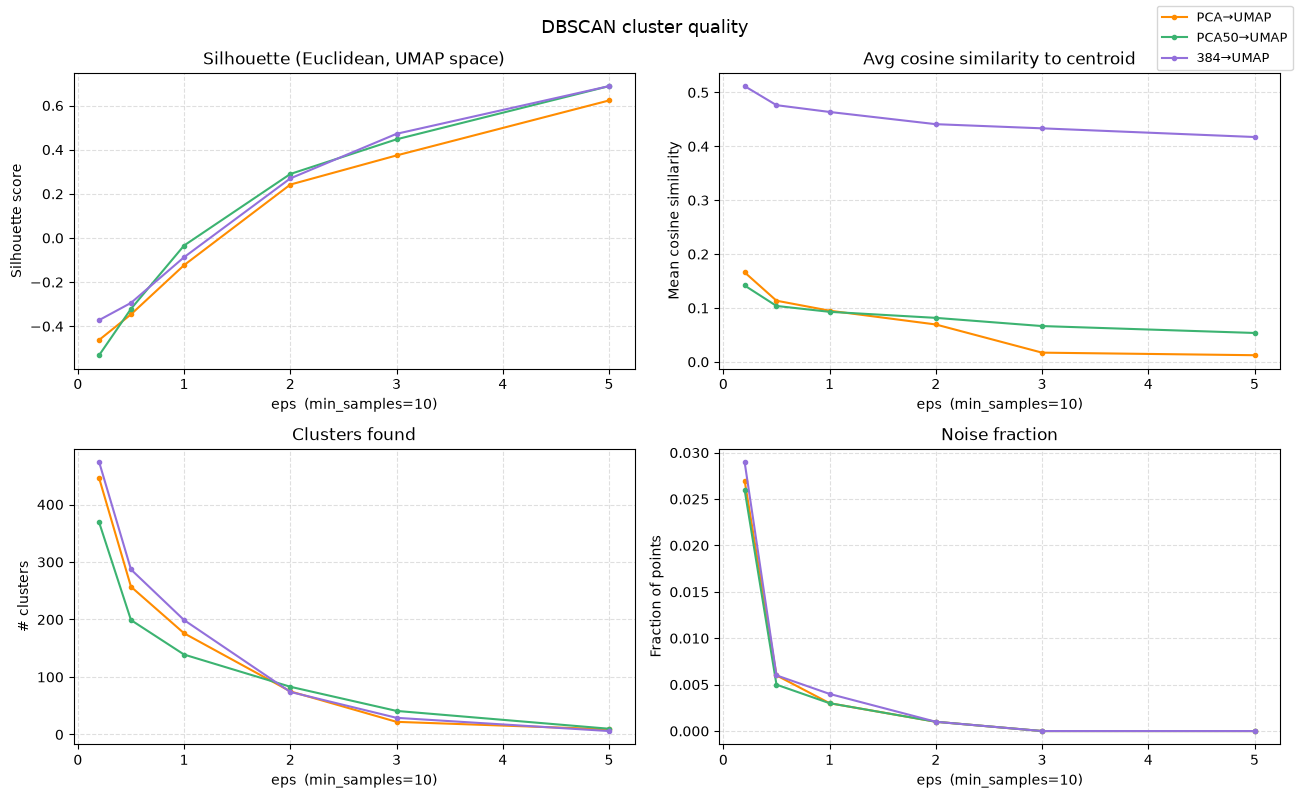

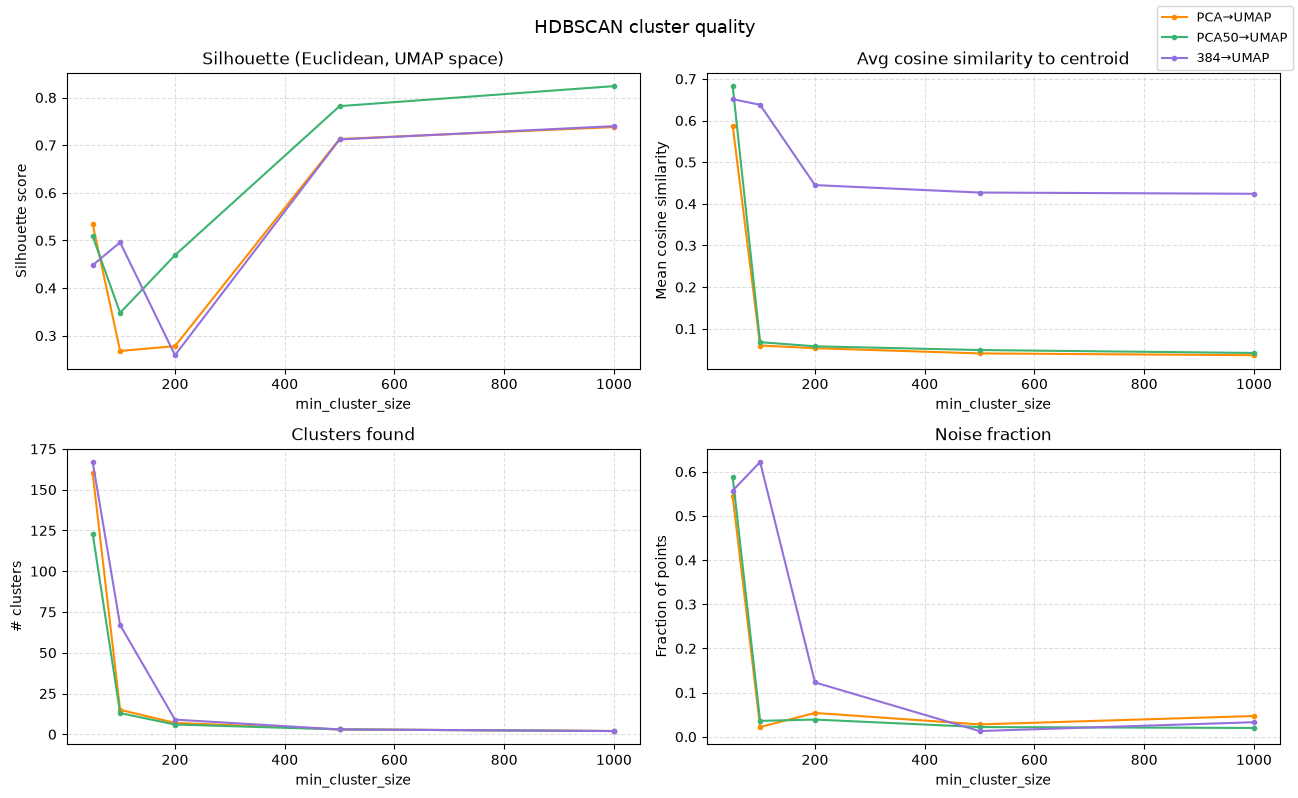

In [66]:
_space_colors = {
    "PCA→UMAP":   "darkorange",
    "PCA50→UMAP": "mediumseagreen",
    "384→UMAP":   "mediumpurple",
}

def _plot_density_quality(quality, param_label, suptitle):
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    (ax_sil, ax_cos), (ax_nk, ax_nf) = axes

    for sname, param_dict in quality.items():
        xs   = sorted(param_dict.keys())
        c    = _space_colors[sname]
        sils = [param_dict[x]["sil"]     for x in xs]
        coss = [param_dict[x]["avg_cos"] for x in xs]
        nks  = [param_dict[x]["n_k"]     for x in xs]
        nfs  = [param_dict[x]["noise"]   for x in xs]

        def _line(ax, ys):
            pairs = [(x, y) for x, y in zip(xs, ys) if not (isinstance(y, float) and np.isnan(y))]
            if pairs:
                vx, vy = zip(*pairs)
                ax.plot(vx, vy, ".-", color=c, label=sname)

        _line(ax_sil, sils)
        _line(ax_cos, coss)
        _line(ax_nk,  nks)
        _line(ax_nf,  nfs)

    for ax, title, ylabel in [
        (ax_sil, "Silhouette (Euclidean, UMAP space)",  "Silhouette score"),
        (ax_cos, "Avg cosine similarity to centroid",   "Mean cosine similarity"),
        (ax_nk,  "Clusters found",                      "# clusters"),
        (ax_nf,  "Noise fraction",                      "Fraction of points"),
    ]:
        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.set_xlabel(param_label)
        ax.grid(linestyle="--", alpha=0.4)

    handles = [
        mlines.Line2D([], [], color=c, marker=".", label=sname)
        for sname, c in _space_colors.items()
    ]
    fig.legend(handles=handles, loc="upper right", fontsize=9)
    fig.suptitle(suptitle, fontsize=13)
    plt.tight_layout()
    plt.show()

_plot_density_quality(dbscan_quality,  f"eps  (min_samples={DBSCAN_MIN_SAMPLES})", "DBSCAN cluster quality")
_plot_density_quality(hdbscan_quality, "min_cluster_size",                          "HDBSCAN cluster quality")
